# ODYCCEUS Tutorial for the `stream_graph` library

## Venice: September 2019

**git-repository**: https://github.com/ysig/stream_graph  
**documentation**: https://ysig.github.io/stream_graph/doc/  
**install**: pip install git+https://github.com/ysig/stream_graph  
**tutorial-dependencies**: pip install bokeh networkx wordcloud  
**feedback**: [raise an issue in github](https://github.com/ysig/stream_graph/issues) **or** email me at `Yiannis.Siglidis@lip6.fr`

# What is a stream-graph?

# İngilizce
A stream-graph is a time-inclusive **generalization** of a static graph.

As we know a static graph, is an object $G = (V, E)$, where:

- $V$, is a set of nodes or the **node-set**
- $E \subseteq V \times V$, is a set of links or the **link-set**


<img src="./karate.png" width="1000">


A stream-graph, is an object $SG = (V, T, W, L)$, where:

- $V$, is a set of nodes or the **node-set**
- $T$, is a collection of time-objects or the **time-set**
- $W \subseteq V \times T$, is a collection of temporal-nodes or the **temporal-node-set**
- $L \subseteq (W \times W) \; / \; T \subseteq V \times V \times T$, is a collection of temporal-links or the **temporal-link-set**


<img src="./sg_example.png" width="1000">

Notice that in a stream-graph we can have both **instantaneous** and interactions with **duration**.

Also for discrete-time, all interactions with **duration**, can be represented as instantaneous interactions.  

We will refer to the **aggregated graph** of a stream-graph as the one defined by it's nodeset V, and all the link that appear inside the temporal-link-set.


# TÜRKÇE

Bir akış çizgesi, statik bir ağın zaman dahil **genellemesi**'dır.

Statik bir ağ bildiğimiz gibi, $G = (V, E)$ bir nesnedir:

- $V$, bir dizi düğüm veya **node-set**
- $E \subseteq V \times V$, bir dizi bağlantı veya **link-set**

<img src="./karate.png" width="1000">

Bir akış çizgesi, $SG = (V, T, W, L)$ bir nesnedir:

- $V$, bir dizi düğüm veya **node-set**
- $T$, zaman nesnelerinin bir koleksiyonu veya **time-set**
- $W \subseteq V \times T$, zamansal düğümlerin bir koleksiyonu veya **temporal-node-set**
- $L \subseteq (W \times W) \; / \; T \subseteq V \times V \times T$, temporal-links veya ** temporal-link-set ** koleksiyonudur

<img src="./sg_example.png" width="1000">

Bir akış çizgesinin hem **anlık(instantaneous)** hem de **Süre(duration)** zamansallıkla ile etkileşimlere sahip olabileceğimize dikkat edin.

Ayrıca ayrık zaman için, **Süre(duration)** ile tüm etkileşimler anlık etkileşimler olarak temsil edilebilir.  

Bir akış çizgesinin **toplu çizge (aggregated graph)** Nodeset V tarafından tanımlandığı gibi ve temporal-bağlantı setinin içinde görünen tüm bağlantıya değineceğiz.

# 1 Loading the dataset

## 1.1 Importing libraries

For visualization in this tutorial, we mainly use the bokeh library.

Bu öğreticide görselleştirme için esas olarak bokeh kütüphanesini kullanıyoruz.

In [3]:
from bokeh.io import output_notebook
from bokeh.plotting import figure, show

output_notebook()

Loading BokehJS ...

and matplotlib

ve matplotlib

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

we will also use an object called `wordCloud`, for displaying circular word-clouds, which you can be installed by `pip install wordcloud`

Ayrıca `wordCloud` adlı bir nesne, `pip install wordcloud` tarafından yüklenebileceğiniz dairesel kelime bulutlarını görüntülemek için kullanacağız.

In [5]:
from wordcloud import WordCloud

for it we initialize a circular mask

Bunun için dairesel bir maskeyi başlatıyoruz

In [6]:
import numpy as np

# Make mask
x, y = np.ogrid[:300, :300]
mask = (x - 150) ** 2 + (y - 150) ** 2 > 130 ** 2
mask = 255 * mask.astype(int)

we will also use networkx, which you can install by `pip install networkx`

Ayrıca, `pip install networkx` kullanarak yüklediğimiz networkx'i kullanacağız

In [7]:
import networkx as nx
nx.__version__

'2.6.3'

## 1.2 Loading the dataset

## English

In this tutorial we will use the `migrants` dataset, dedicated for this summer school, focusing on the unweighted hashtag network.

This dataset consists of two parts:

1. every single hashtag that appears at a certain date.
2. all the pairs of hashtags, that appeared together at a certain date.

To load and preprocess the data, we will use `pandas` library in order, to transform them to a form that suits our `stream_graph` package.

## Türkçe

Bu öğreticide, bu yaz okuluna adanmış, ağırlıksız hashtag ağına odaklanan `migrants` veri kümesini kullanacağız.

Bu veri kümesi iki bölümden oluşur:

1. Belirli bir tarihte görünen her bir hashtag.
2. Belirli bir tarihte birlikte ortaya çıkan tüm hashtag çiftleri.

Verileri yüklemek ve önceden işlemek için, `pandas` kütüphanesini sırayla kullanacağız, bunları` stream_graph` paketimize uygun bir forma dönüştüreceğiz.

In [8]:
import pandas as pd

We first load the **csv** file, corresponding to the *temporal-node-set*, as a two column `(u, date)` dataframe of hashtags at each day.  
In order to avoid the interpretation of some hashtags as `nan` values, we would set `keep_default_na` parameter, to `False` in order to interpret everything as a `string`.

Önce **csv** dosyasını,*temporal-node-set*'e karşılık gelen iki sütun olarak `(u, date)` her gün hashtag'lerin veri çerçevesi olarak yükleriz.  
Bazı hashtag'lerin `nan` değerleri olarak yorumlanmasını önlemek için, her şeyi `string' olarak yorumlamak için `keep_default_na` parametresini `False` olarak ayarlardık.


In [9]:
tns_df = pd.read_csv('migrant-day-hashtag-simple.zip', names=['date', 'u'], sep=' ', keep_default_na=False)
tns_df.head()

,date,u
0,2015-01-01,シンクビー
1,2015-01-01,エイネーション
2,2015-01-01,01_january
3,2015-01-01,1amthoughts
4,2015-01-01,1u


The second **csv** file we load, corresponds to the *temporal-link-set*, as a dataframe of columns `(u, v, date)`, of hashtag couples and the dates at which they appear. Also for the purpose of this tutorial we will refer to a temporal-link-set by the letter $L$. A classic `link-set` will be notated as $E$.

Yüklediğimiz ikinci **csv** dosyası, hashtag çiftlerinin ve göründükleri tarihlerin `(u, v, date)` sütunlarının bir veri çerçevesi olarak *temporal-link-set*e karşılık gelir. Ayrıca bu öğreticinin amacı için $L$ harfiyle geçici bağlantı setine başvuracağız. Klasik bir `link-set` $E$ olarak not edilecektir.

In [10]:
tls_df = pd.read_csv('migrant-day-hashtag-hashtag-simple.zip', names=['date', 'u', 'v'], sep=' ', keep_default_na=False)
tls_df.head()

,date,u,v
0,2015-01-01,1u,immigration
1,2015-01-01,1vandaag,kukluxklan
2,2015-01-01,1vandaag,rednecks
3,2015-01-01,20h,blueskym
4,2015-01-01,20h,france2


We will first remove the rows, that contain the hashtags that where used as keywords in order to extract this dataset, which are: `migrants, migrant, immigrant, immigrants, emigrants, emigrant`.

Önce bu veri kümesini çıkarmak için anahtar kelimeler olarak kullanılan hashtag'leri içeren satırları kaldıracağız: `migrants, migrant, immigrant, immigrants, emigrants, emigrant`.

In [11]:
remove_words = {'migrant', 'migrants', 'immigrant', 'immigrants', 'emigrant', 'emigrants'}
tns_df = tns_df[~tns_df.u.isin(remove_words)]
tls_df = tls_df[~tls_df.u.isin(remove_words) & ~tls_df.v.isin(remove_words)]

In order for our data to be supported by our library we **need** to substitute the date's with integers.  
As the temporal-node-set should contain the temporal-link-set time-wise, we will make a map of all the dates, from all those appearing inside the first.

Verilerimizin kütüphanemiz tarafından desteklenmesi için tarihi tamsayılarla değiştirmemiz **gerekir**.
Temporal düğüm kümesi zamansal-bağlantı seti zaman açısından **içermesi gerektiğinden**, birincinin içinde görünen tüm tarihlerin bir haritasını yapacağız.

In [12]:
date_to_t = {date: i for i, date in enumerate(sorted(list(set(tns_df['date']))))}

and calculate it's inverse for later use (that is for displaying our results).

ve daha sonra kullanım için ters olduğunu hesaplayın (sonuçlarımızı görüntülemek içindir).

In [13]:
t_to_date = {i: date  for date, i in date_to_t.items()}

and a function that can turn that into a displayable object

ve bunu görüntülenebilir bir nesneye dönüştürebilen bir işlev

In [14]:
def to_date(t):
    return pd.to_datetime(t_to_date[t], format='%Y-%m-%d')

Now let's apply the map:

Şimdi haritayı uygulayalım:

In [15]:
tns_df['ts'] = tns_df['date'].map(date_to_t)
tls_df['ts'] = tls_df['date'].map(date_to_t)

and drop the redundant columns

ve gereksiz sütunları bırakın

In [16]:
tns_df.drop(columns=['date'], inplace=True)
tls_df.drop(columns=['date'], inplace=True)

So, after the transform we have:

Yani, dönüşümden sonra:

In [17]:
tns_df.head()

,u,ts
0,シンクビー,0
1,エイネーション,0
2,01_january,0
3,1amthoughts,0
4,1u,0


In [18]:
tls_df.head()

,u,v,ts
0,1u,immigration,0
1,1vandaag,kukluxklan,0
2,1vandaag,rednecks,0
3,20h,blueskym,0
4,20h,france2,0


## 1.3 Represent as a Stream Graph

So now we have the right format to initialize our `temporal-node-set` and `temporal-link-set`.  
As you can notice we have discrete-time, non-weighted, instantaneous data-frame.  
We will first import all the classes we our going to use.

Şimdi `temporal-node-set` ve `temporal-link-set` ni başlatmak için doğru biçime sahibiz.
Fark edebileceğiniz gibi, ayrı zamanlı, ağırlıklı olmayan, anlık veri çerçevemiz var.
Önce kullanacağımız tüm sınıfları içe aktaracağız.

In [19]:
from stream_graph import ITemporalNodeSetDF, ITemporalLinkSetDF, StreamGraph

We will pass the value `True` to parameter `discrete` to indicate so.

Bunu belirtmek için `True` değerini `discrete` parametresine geçireceğiz.

In [20]:
tns = ITemporalNodeSetDF(tns_df, discrete=True)
tls = ITemporalLinkSetDF(tls_df, discrete=True)

A stream-graph, is a collection of a `node-set`, a `time-set`, a `temporal-node-set` and a `temporal-link-set`.  
So, to initialize a StreamGraph we also need a `node-set` and a `time-set`.  
We extract both from the `temporal-node-set`.  

Bir akış grafi, bir `node-set` (düğüm seti), bir `time-set` (zaman seti), bir `temporal-node-set` (zamansal düğüm seti) ve bir `temporal-link-set` (zamansal kenar seti) i koleksiyonudur.
Dolayısıyla, bir StreamGraph'ı başlatmak için bir `node-set` ve bir `time-set` de ihtiyacımız var.
Bu ikisini `temporal-node-set`ten türeteceğiz.

In [21]:
ns, ts = tns.nodeset, tns.timeset

and initialize our **StreamGraph** as a collection of $(V,\;T,\;W,\;L)$.

ve **StreamGraph** 'nı $(V,\;T,\;W,\;L)$ bir koleksiyon olarak başlatın.

In [22]:
sg = StreamGraph(ns, ts, tns, tls)

Now let's plot a small and dense subset of the graph. Displaying days from 0 to 20, we choose keep only the nodes that are part of the first 5 links, which have a duration bigger than 6 and smaller than 15.

Şimdi ağın küçük ve yoğun bir alt kümesini çizelim. 0'dan 20'ye kadar gün görüntüleyerek, yalnızca 6'dan daha büyük ve 15'ten daha küçük bir süreye sahip ilk 5 bağlantının bir parçası olan düğümleri tutmayı seçiyoruz.

In [23]:
from stream_graph import Visualizer

nsu, nsv = zip(*[u for u,d in ITemporalLinkSetDF(tls_df[tls_df.ts <= 20], discrete=True).duration_of() if d>5 and d<15][:5])
sgv = sg.substream(nsu, nsv, [(0, 20)])
Visualizer(y_axis_label='#hashtags').fit(sgv).show()

## 2. Measures

In this section, we will examine a bunch of elementary measures, that are related with the objects that constitute the stream-graph.  
This objects can be referenced as `sg.nodeset_`, `sg.timeset_`, `sg.temporal_nodeset_`, `sg.temporal_linkset_`.  
The underscore here is used to indicate that this class attributes are protected. By commiting it we will get copies.

Bu bölümde, akış çizgesini oluşturan nesnelerle ilgili bir sürü temel ölçütü inceleyeceğiz.
Bu nesnelere `sg.nodeset_`, `sg.timeset_`, `sg.temporal_nodeset_`, `sg.temporal_linkset_` olarak atıfta bulunulabilir.
Buradaki alt çizgi, bu sınıf niteliklerinin korunduğunu belirtmek için kullanılır. Bunu taahhüt ederek kopya alacağız.

### 2.1 Global Measures

- First we count the number of different hashtags: $|V|$
- Önce farklı hashtag sayısını sayıyoruz: $|V|$

In [24]:
nnodes = sg.nodeset_.size
nnodes

291892

- the number of days that our data spans through: $|T|$
- Verilerimizin geçtiği gün sayısı: $|T|$

In [25]:
ntimes = sg.timeset_.size
ntimes

546

- the sum of all hashtags at each day: $|W|$
- Her gün tüm hashtag'lerin toplamı: $|W|$

In [26]:
sg.temporal_nodeset_.size

1770866

- calculate the number of nodes, of the Stream-Graph:
- Bu akışın düğüm sayısını hesaplayacağız:

 $$n_{SG} = \sum_{u\in V}n_{u} = \sum_{u\in V}\frac{|T_{u}|}{|T|} = \frac{|W|}{|T|} $$

In [27]:
sg.n

3243.3443223443223

- and calculate the coverage of the stream-graph:
- ve akış çizgesinin kapsamını (coverage) hesaplayacağız:

 $$c(SG) = \frac{|W|}{|V \times T|} = \frac{|W|}{|V| |T|} = \frac{\frac{|W|}{|T|}}{|V|} = \frac{n_{SG}}{|V|}$$

In [28]:
sg.coverage

0.011111453285270998

which indicates us, that the temporal-node-set is *dynamically rich*.   
Furthermore, we can visualize through a wordcloud which hashtags, appear for the most days (**contribute** more).

Bu, zamansal düğüm kümesinin *dinamik olarak zengin(dynamically rich)* olduğunu gösterir.
Ayrıca, hashtag'lerin en çok gün boyunca görünen bir WordCloud aracılığıyla görselleştirebiliriz (daha fazla katkıda bulunabilir).

$$n_{u} = \frac{|T_{u}|}{|T|}$$

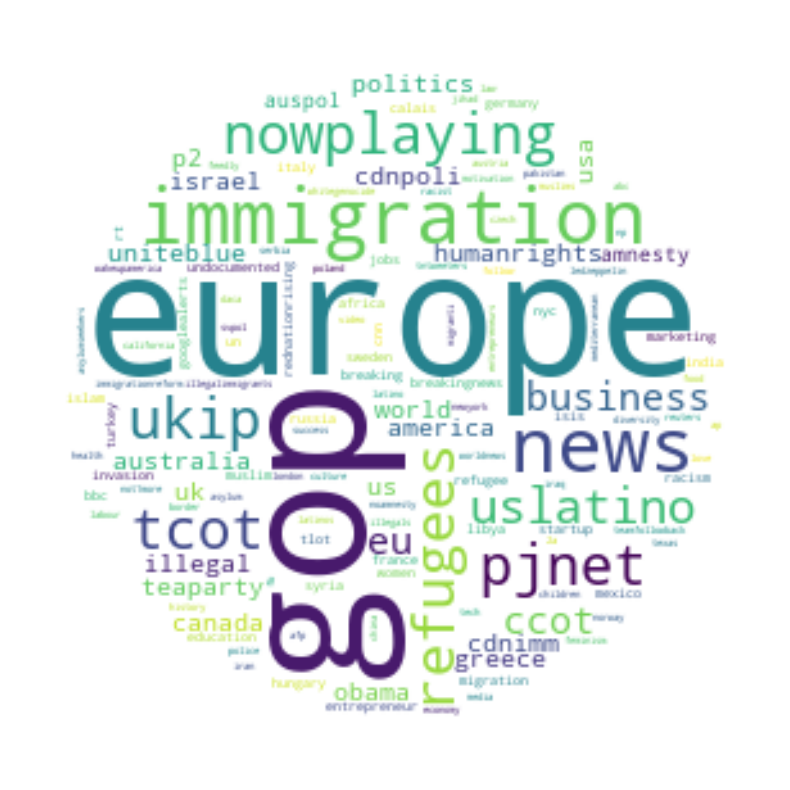

In [29]:
# WordCloud
wc = WordCloud(background_color="white", repeat=True, mask=mask)
wc.fit_words(dict(sg.node_contribution_of()))

# 
plt.rcParams["figure.figsize"] = (10, 10)
plt.axis("off")
plt.imshow(wc, interpolation="bilinear")
plt.show()

- Also, we will calculate the number of interactions, i.e. the number of hashtag couples: $|L|$
- Ayrıca, etkileşim sayısını hesaplayacağız, yani hashtag çiftlerinin sayısı: $|L|$

In [30]:
sg.temporal_linkset_.number_of_interactions

6898973

- We will calculate the number of links, of the Stream-Graph:
- Bu akışın kenar sayısını hesaplayacağız:


 $$m_{SG} = \sum_{u,v \in V}m_{uv} = \sum_{u,v\in V}\frac{|T_{uv}|}{|T|} = \frac{|L|}{|T|}$$

In [31]:
sg.m

12635.481684981685

In a classical graph $G$, the *density* is defined as:
Klasik bir grafikte $G$, *yoğunluk(density)* şu şekilde tanımlanır:

 $$\delta(G) = \frac{|E|}{|V|(|V|-1)}$$

In a stream-graph $SG$, this is generalized by defining the density as:
Bir akış çizgesinde ise $SG$, yoğunluğu şu şekilde tanımlayarak genelleştirilir:

 $$\delta(SG) = \frac{\sum_{uv \in V}|T_{uv}|}{\sum_{uv \in V}|T_{u} \cap T_{v}|} = \frac{|L|}{\sum_{uv \in V}|T_{u} \cap T_{v}|}$$

In [32]:
sg.density

0.002106755140012308

from which we an observe, that our stream-graph is really sparse.
Bir gözlemlediğimiz yoğunluk değeri (0.002106755140012308), akış çizgemizin gerçekten seyrek olduğunu göstermektedir.

- Additionaly, we calculate the number of **distinct** hashtag couples $|E|$
- Ek olarak, **distinct** hashtag çiftlerinin sayısını hesaplıyoruz $|E|$.

In [33]:
sg.temporal_linkset_.m

2495480

### 2.2. Time dimension

In this section we provide some plots, by exploring the data along the time dimension.
Bu bölümde, zaman boyutu boyunca verileri inceleyerek bazı grafikler sunuyoruz.

- first we plot the number of nodes through time, i.e. the number of different hashtags that appear on each day $|V(t)|$
- Önce zaman içinde düğüm sayısını çiziyoruz, yani her gün $|V(t)|$

In [34]:
tv = sg.temporal_nodeset_.n_at()

In [35]:
t, value = zip(*((to_date(t), v) for t, v in tv))
p = figure(x_axis_type="datetime")
p.vbar(x=t, top=value, width=1, line_color="blue")
show(p)

- additionally, we plot a curve of the number of interactions through time, that is the number of different hashtag couples that appear on each day $$|E(t)|$$
- Ayrıca, zaman içinde etkileşim sayısının bir eğrisini çiziyoruz, yani her gün görünen farklı hashtag çiftlerinin sayısı $$|E(t)|$$

In [36]:
tv = sg.temporal_linkset_.m_at()

In [37]:
t, value = zip(*((to_date(t), v) for t, v in tv))
p = figure(x_axis_type="datetime")
p.vbar(x=t, top=value, width=1, line_color="green")
show(p)

- now, if we calculate the density at a given point in time:
- Şimdi, yoğunluğu belirli bir noktada hesaplarsak:

 $$\delta(t) = \frac{|E(t)|}{|V(t)|(|V(t)|-1)}$$

In [38]:
tv = sg.density_at()

In [39]:
t, value = zip(*((to_date(t), v) for t, v in tv))
p = figure(x_axis_type="datetime")
p.vbar(x=t, top=value, width=1, line_color="#a23420")
show(p)

We can see a very different plot than the previous one. Notice that spikes can correspond to days where the hashtags coappear most (we have a more strong topic), but can generally be caused by really small values of $|V(t)|$.
Bir öncekinden çok farklı bir arsa görebiliriz. Artışların hashtag'lerin en çok (daha güçlü bir konuya sahip olduğumuz) günlere karşılık gelebileceğine dikkat edin, ancak genellikle gerçekten küçük $|V(t)|$ değerlerinden kaynaklanabilir.

- Now for one particular hashtag ('germany'), we display the number of hashtags related to this given hashtag, on each day. 
- Şimdi belirli bir hashtag ('germany') için, her gün verilen hashtag ile ilgili hashtag sayısını gösteriyoruz.

In [40]:
tv = sg.temporal_linkset_.degree_at(u='germany')

In [41]:
t, value = zip(*((to_date(t), v) for t, v in tv))
p = figure(x_axis_type="datetime")
p.vbar(x=t, top=value, width=1, line_color="black")
show(p)

- and we compare it with the `neighbor_coverage` of the hashtag, for each day:
- Ve her gün için hashtag'in `neighbor_coverage` ile karşılaştırıyoruz:

$$\frac{|N_{t}(u)|}{|V(t)|}$$

In [42]:
tv = sg.neighbor_coverage_at(u='germany')

In [43]:
t, value = zip(*((to_date(t), v) for t, v in tv))
p = figure(x_axis_type="datetime")
p.vbar(x=t, top=value, width=1, line_color="black")
show(p)

By doing so, we can observe that around '09/2015' `#germany` is not that significant as it is at the spike after '01/2016', indicating that at the first case we have a general rise of tweets (as we can see on the above plots) and not one dedicated to germany.

Bunu yaparak, '09/2015 '`#germany` 01/2016'dan sonra başakta olduğu kadar önemli olmadığını gözlemleyebiliriz, ilk durumda (yukarıdaki grafiklerde görebileceğimiz gibi) Almanya'ya adanmış olanı değil, genel bir tweet yükselişine sahip olduğumuzu gösterir.

### 2.3 Structural dimension

We can also aggregate over time and uncover the structural dimension of our data.

Ayrıca zaman içinde toplanabilir ve verilerimizin yapısal boyutunu ortaya çıkarabiliriz.

- firstly, we calculate the *global degree* of hashtags, i.e. the sum of the number of neighbors of a hashtag for each day:
- İlk olarak, hashtag'lerin *global degree* hesaplıyoruz, yani her gün için bir hashtag komşu sayısının toplamı:

 $$D_{u} = \sum_{t}|N_{u}(t)|$$

and get the list of the hasthags with the highest *global degree*, i.e. hastags which co-appear with most hashtags, cumulatively, for all the days.
ve en yüksek *global degree* ile hashagların listesini alın, yani tüm günler boyunca kümülatif olarak çoğu hashtag ile birlikte görünen hastags.

In [44]:
u, d = zip(*sg.temporal_linkset_.degree_of())
top_20 = pd.DataFrame({'#': u, 'degree': d}).sort_values(by=['degree'], ascending=False).head(20)
del u, d

In [45]:
p = figure(y_range=top_20['#'])
p.hbar(y=top_20['#'], right=top_20['degree'], height=0.5)
show(p)

- for these hashtags we will investigate the amount of days they co-appear and present it in a heatmap.
  For that we will calculate the duration (number of days) of a pair of hashtags $|T_{uv}|$

- Bu hashtag'ler için birlikte göründükleri ve bir ısı haritasında sundukları gün miktarını araştıracağız.
Bunun için bir çift hashtag'in süresini (gün sayısı) hesaplayacağız. $|T_{uv}|$

In [46]:
ld = sg.temporal_linkset_.duration_of()

In [47]:
valid_hashtag = set(top_20['#'])
hhd = [(a, b, d) for ((a, b), d) in ld if a in valid_hashtag and b in valid_hashtag]
hm_x, hm_y, hm_z = zip(*hhd)

extract the subset that we want

İstediğimiz alt kümeyi çıkarın

In [48]:
from bokeh.models import BasicTicker, ColorBar, LinearColorMapper, ColumnDataSource, PrintfTickFormatter
from bokeh.transform import transform
from bokeh.palettes import plasma

# Structure the data
source = {'#1': hm_x, '#2':  hm_y, 'value': hm_z}

# You can use your own palette here
colors = plasma(20)[::-1]

# Had a specific mapper to map color with value
mapper = LinearColorMapper(palette=colors, low=min(hm_z), high=max(hm_z))

# Make the figure
p = figure(x_range=list(top_20['#']), y_range=list(top_20['#']))
p.rect(source=source, x='#1', y='#2', width=1, height=1, fill_color=transform('value', mapper))

# Add legend
color_bar = ColorBar(color_mapper=mapper, location=(0, 0),
                     ticker=BasicTicker(desired_num_ticks=len(colors)))

p.add_layout(color_bar, 'right')
p.xaxis.major_label_orientation = 3.14/4
show(p)

- Also we plot the distribution of those durations for each hashtag.
- Ayrıca her bir hashtag için bu sürelerin dağılımını gösterelim.

In [49]:
DF = pd.DataFrame([(a, b, d) for ((a, b), d) in ld], columns=['#1', '#2', 'duration'])
del ld

In [50]:
from collections import Counter
ct = Counter(DF['duration'])
x, d = zip(*sorted(list(ct.items())))
p = figure(x_axis_type="log", y_axis_type="log")
p.vbar(x=x, top=d, width=1, bottom=1)
show(p)

We will now extract the most couple of hashtags, by keeping only those which have a duration higher that of more than 430 days. We will respresent them as a Graph, coverting them from our-library's `graph` to `networkx`.  We selected 430, by trial an error as we wanted the resulted graph be visible, when plotted.

Şimdi sadece 430 günden fazla olanı daha yüksek olanları koruyarak en çok hashtag'i çıkaracağız. Bunları, `networkx` iismli kütüphane ile bir ağ olarak hazırlayacağız.  Çizildiğinde sonuçlanan grafiğin görünür olmasını istediğimiz için deneme için  430'u seçtik.

In [51]:
from stream_graph import LinkSetDF
gr = LinkSetDF(DF[DF['duration'] > 430], weighted=True).as_graph
del DF
gr.n, gr.m

(63, 162)

Now let's convert our graph object to a networkx graph, to plot it.

Şimdi grafik nesnemizi çizmek için bir NetworkX grafiğine dönüştürelim.

In [52]:
G = gr.to_networkx()

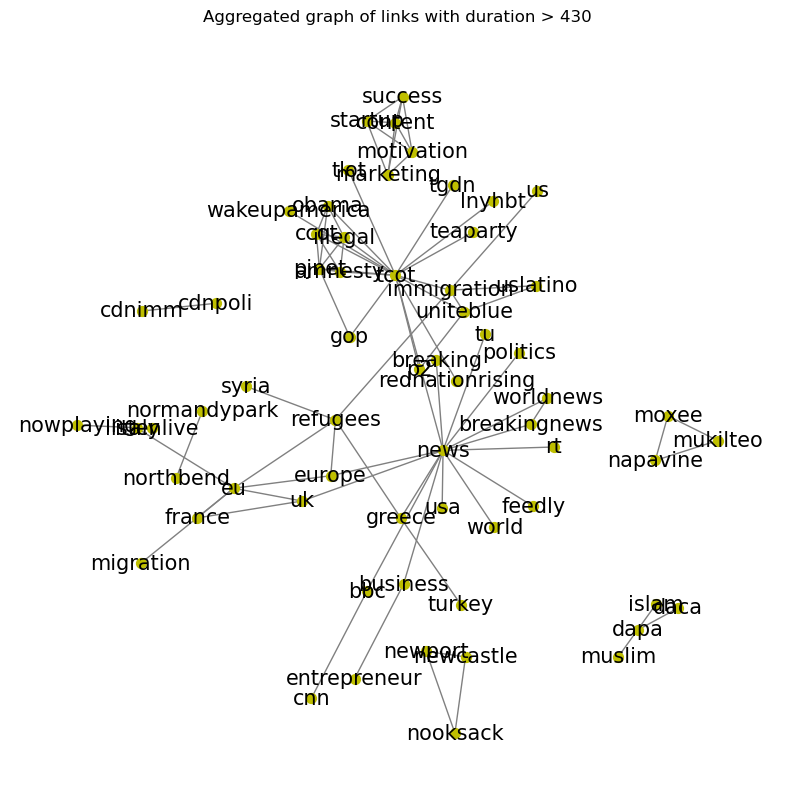

In [53]:
# Layout
pos=nx.spring_layout(G, k=3)

nx.draw_networkx_nodes(G, pos, node_color='y', node_size=50)
nx.draw_networkx_edges(G, pos, width=1, edge_color='grey')
nx.draw_networkx_labels(G, pos, font_size=15)

# Plot the graph
plt.rcParams["figure.figsize"] = (10, 15)
plt.axis('off')
plt.title('Aggregated graph of links with duration > 430')
plt.show()

## 3.Complex measures

A lot of measures of the classical graph theoy can be generalized to Stream-Graphs.
From maximal-cliques and k-cores, to paths and closeness measures, people in our team are developing algorithms and code, in order to have these tools at hand in the future.

Klasik ağların birçok ölçütü, akış çizgelerine genelleştirilebilir.
maximal-cliques ve k-cores, yollara ve yakınlık ölçülerine kadar, ekibimizdeki insanlar gelecekte bu araçların el altında olması için algoritmalar ve kod geliştiriyorlar'mış'. (Proje 6 Yıl önce sonranmış)


For the purpose of this tutorial, we focus on the time-period after the first day and before the '01/04/2015'.  
We also keep the hashtags that appear for at-least 20 days (i.e. 20 times) in the temporal-node-set.
In this dsubset of the data, we calculate measures of centrality and maximal-cliques.

Bu öğreticinin amacı için, ilk günden sonra ve '01/04/2015'ten önce zaman dönemi üzerine odaklanıyoruz.
Ayrıca, temporal düğüm setinde 20 gün (yani 20 kez) görünen hashtag'leri de saklıyoruz.
Verilerin bu dsubsetinde, merkeziyet ve maksimum plikasyon ölçümlerini hesaplıyoruz.

In [54]:
t_to_date[0]

'2015-01-01'

In [55]:
sg_sub = sg.substream(ts=[(0, date_to_t['2015-04-01'])])

In [56]:
nd = {n: d for n, d in sg_sub.temporal_nodeset_.duration_of() if d >= 20}
u = set(nd.keys())
len(u)

1606

We display the word cloud, which can be produced by the frequency of all these nodes.

Tüm bu düğümlerin frekansıyla üretilebilen kelime bulutunu sergiliyoruz.

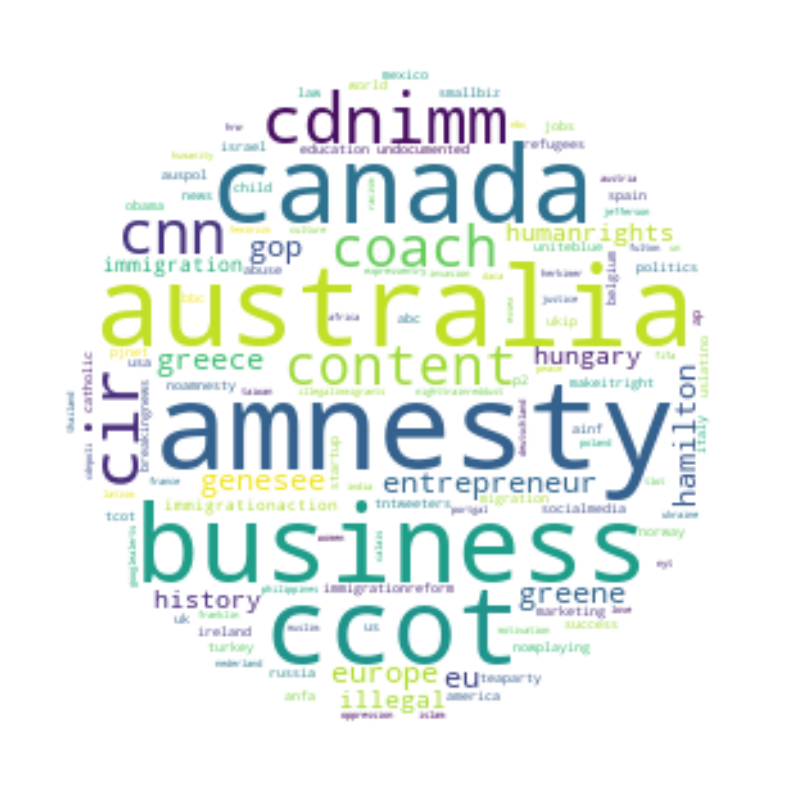

In [57]:
# fit node-duration
wc = WordCloud(background_color="white", repeat=True, mask=mask)
wc.fit_words(nd)

# plot
plt.rcParams["figure.figsize"] = (10, 10)
plt.axis("off")
plt.imshow(wc, interpolation="bilinear")
plt.show()

Now if we keep only the nodes that appear for at-least 20 days

Şimdi sadece 20 gün boyunca görünen düğümleri saklarsak

In [58]:
sg_sub = sg_sub.substream(nsu=u, nsv=u)
sg_sub.temporal_linkset_.df_.shape

(324550, 3)

and extract the aggregated graph.

ve toplanmış grafiği çıkarın.

In [59]:
agg = sg_sub.aggregated_graph.to_networkx()

### 3.1. Closeness-Centrality

# English

In a classical graph, closeness centrality (or closeness) of a node is a measure of centrality in a network, calculated as the reciprocal of the sum of the length of the shortest paths, between the node and all other nodes in the graph. Thus, the more central a node is, the closer it is to all other nodes.

Closeness was defined by Bavelas (1950) as the reciprocal of the farness that is:
$$C(v) = \frac{1}{\sum_{u \neq v}d(u, v)}$$

<img src="./cg.png" width="700">


In this graph we can observe that the node with the highest closeness is the black.
We calculate, for each hashtag in the aggregated static graph, it's closeness-centrality


# Türkçe

Klasik bir ağda, bir düğümün yakınlık merkeziliği (veya yakınlığı), bir ağda, düğüm ve grafikteki diğer tüm düğümler arasındaki en kısa yolların uzunluğunun toplamı olarak hesaplanan bir merkeziyet ölçüsüdür. Böylece, bir düğüm ne kadar merkezi olursa, diğer tüm düğümlere o kadar yakın olur.

Yakınlık, bavelas (1950) tarafından yapılandırın karşılıklı olarak tanımlanmıştır:
$$C(v) = \frac{1}{\sum_{u \neq v}d(u, v)}$$

<img src="./cg.png" width="700">


Bu grafikte, en yüksek yakınlığa sahip düğümün siyah olduğunu gözlemleyebiliriz.
Toplu statik ağda her bir hashtag için hesaplıyoruz. Bu yakınlık merkezliğidir.

In [60]:
%%time
cc = nx.closeness_centrality(agg)

Wall time: 5.65 s


In [61]:
DF_c = pd.DataFrame([(u, c) for u, c in cc.items()], columns=['#', 'closeness'])
top_20 = DF_c.sort_values(by=['closeness'], ascending=False).head(20)

and plot the top 20

ve ilk 20'yi gösterelim

In [62]:
p = figure(y_range=top_20['#'])
p.hbar(y=top_20['#'], right=top_20['closeness'], height=0.5)
show(p)


# İngilizce

Temporal-closeness-centrality defined by Matthieu Latapy et al. (2017), is similarly equal to:
$$C_{t}(v) = \frac{1}{\sum_{u \neq v}d_{t}(u, v)}$$

Where $d_{t}(u, v)$ represents the distance of u to v at time t.
So this measure of temporal-closeness-centrality can 1) vary through time and 2) be different from the value of the classical-closeness-centrality on the aggregated graph.

The importance of having temporal closeness, can be illustrated on the following plot:

<img src="./closeness_example.png" width="800">

Finally, notice that this measure of temporal-closeness is different from calculating the classic closeness on the snapshot graph (on the graph active at each time-stamp), as paths of the past have an importance for calculating a value at a current time-stamp.

# Türkçe


Matthieu Latapy ve ark. (2017), benzer şekilde eşittir:
$$C_{t}(v) = \frac{1}{\sum_{u \neq v}d_{t}(u, v)}$$

Burada $d_{t}(u, v)$ u'dan V'ye mesafesini t zamanında temsil eder.
Dolayısıyla, bu zamansal-closiness-santralitenin bu ölçüsü 
1) zamanla değişebilir
2) toplu grafikteki klasik-closiness-santralinin değerinden farklı olabilir.
Geçici yakınlığa sahip olmanın önemi, aşağıdaki arsada gösterilebilir:

<img src="./closeness_example.png" width="800">

Son olarak, bu zamansal kapanıklık ölçüsünün, anlık görüntü grafiğindeki (her zaman damgasında aktif olan grafikte) klasik yakınlığı hesaplamaktan farklı olduğuna dikkat edin, çünkü geçmişin yolları mevcut bir zaman damgasındaki bir değeri hesaplamak için bir önemi vardır.

In [63]:
%%time
tc = sg_sub.temporal_linkset_.closeness(t='max')

Wall time: 1min 53s


and present the top-20 hashtags according to closeness

ve yakınlığa göre en iyi 20 hashtag'leri gösterelim

In [64]:
DF_tc = pd.DataFrame([(u, mxc, ts) for u, (mxc, ts) in tc], columns=['#', 'max-closeness', 'ts']).sort_values(by=['max-closeness', 'ts'], ascending=False)
top_20 = DF_tc.head(20)

In [65]:
y, r = zip(*[(str(u) + "@ " + t_to_date[t], c) for u, c, t in top_20.itertuples(name=None, index=False)])
p = figure(y_range=y)
p.hbar(y=y, right=r, height=0.5)
show(p)

- also we plot and compare the temporal-closeness-centrality for two given nodes, through time

- Ayrıca, zaman içinde verilen iki düğüm için zamansal-closessess-santraliteyi çiziyoruz ve karşılaştırıyoruz

In [66]:
tv_md = sg_sub.temporal_linkset_.closeness(u='mediterranean')
tv_usa = sg_sub.temporal_linkset_.closeness(u='usa')

In [67]:
t_md, v_md = zip(*((to_date(t), v) for t, v in tv_md))
t_usa, v_usa = zip(*((to_date(t), v) for t, v in tv_usa))

p = figure(x_axis_type="datetime")
p.step(x=t_md, y=v_md, line_color="blue", mode="after", legend='mediterranean')
p.step(x=t_usa, y=v_usa, line_color="red", mode="after", legend='usa')
show(p)

As we see by comparing these two plots, the hashtag 'mediterran', starts being raised to a **central** topic inside the February of 2015 and 'usa' becomes a bit more central for this region, indicating a possible correlation between these two topics.

Bu iki görseli karşılaştırarak gördüğümüz gibi, 'Akdeniz' hashtag'i, 2015 Şubat ve 'ABD' içindeki **merkezi** konusuna yükseltilmeye başlar ve bu bölge için biraz daha merkezi hale gelir ve bu iki konu arasında olası bir korelasyon olduğunu gösterir.

## 3.2 Maximal-Cliques



A clique in a classic graph is defined as a set of nodes, where there exists a link between all pairs of nodes (subgraphs of density 1).
Klasik bir ağdaki bir klik, tüm düğüm çiftleri arasında bir bağlantı bulunduğu bir düğüm kümesi olarak tanımlanır (yoğunluk 1 alt çizgileri).


<img src="./graph-clique.png" width="500">


In [68]:
cliques = nx.find_cliques(agg)

and print the top-10 maximal-cliques, sorted by size

ve boyuta göre sıralanmış en iyi 10 maksimum plikleri yazdırın

In [69]:
sorted_cliques = sorted(list(cliques), key=lambda x:len(x), reverse=True)
for c in sorted_cliques[:10]:
    print(', '.join(c), end='\n\n')

immigration, dhs, gop, obama, tcot, executiveaction, republicans, immigrationaction, latino, undocumented, daca, immigrationreform, texas, dreamers, tntweeters, uslatino, latinos, latism, dapa

immigration, dhs, gop, obama, tcot, executiveaction, republicans, immigrationaction, latino, undocumented, daca, immigrationreform, cir, dreamers, tntweeters, uslatino, latinos, latism, dapa

immigration, dhs, gop, obama, tcot, p2, immigrationreform, immigrationaction, uniteblue, texas, latino, republicans, daca, undocumented, dreamers, tntweeters, uslatino, latinos, latism

immigration, dhs, gop, obama, tcot, p2, immigrationreform, immigrationaction, uniteblue, cir, republicans, daca, latino, undocumented, dreamers, tntweeters, uslatino, latinos, latism

immigration, dhs, gop, obama, tcot, p2, immigrationreform, immigrationaction, dapa, dreamers, daca, undocumented, tntweeters, latism, republicans, uslatino, latino, latinos, texas

immigration, dhs, gop, obama, tcot, p2, immigrationreform, immi

In a similar fashion with static graphs, a clique in a temporal-link-set is a collection of nodes that are all connected with each other during a given period of time.

Statik grafiklerle benzer bir şekilde, zamansal bağlantı setindeki bir klik, belirli bir süre boyunca birbiriyle bağlantılı olan bir düğüm koleksiyonudur.


<img src="./link-stream-clique.png" width="800">

In [70]:
%%time
mxc = sg_sub.temporal_linkset_.get_maximal_cliques()

Wall time: 44min 1s


and again print the top-6, sorted by size

ve yine boyuta göre sıralanmış ilk 6'yı yazdırın

In [71]:
sorted_cliques = sorted(list(mxc), key=lambda x:(len(x[0]), x[1][1] - x[1][0]), reverse=True)
for c, t in sorted_cliques[:6]:
    print(t_to_date[t[0]],'->',t_to_date[t[1]],':',', '.join(c), end='\n\n')

2015-02-02 -> 2015-02-10 : tntweeters, republicans, dreamers, america, immigration, tcot, uslatino, teaparty, p2, cir, immigrationaction, latism, immigrationreform, gop, uniteblue, obama

2015-02-02 -> 2015-02-10 : tntweeters, republicans, america, immigration, tcot, uslatino, teaparty, p2, usa, cir, immigrationaction, latism, immigrationreform, gop, uniteblue, obama

2015-02-01 -> 2015-02-17 : tntweeters, republicans, latism, dreamers, immigrationreform, gop, immigration, uniteblue, america, tcot, obama, uslatino, teaparty, p2, cir

2015-02-01 -> 2015-02-15 : tntweeters, republicans, latism, immigrationreform, gop, immigration, uniteblue, america, tcot, obama, uslatino, teaparty, p2, usa, cir

2015-02-02 -> 2015-02-13 : immigrationaction, tntweeters, latism, dreamers, immigrationreform, america, immigration, uniteblue, gop, tcot, uslatino, teaparty, obama, p2, cir

2015-02-01 -> 2015-02-10 : immigrationaction, tntweeters, republicans, latism, dreamers, immigrationreform, gop, immigrat

but we can also print the top-6, sorted by duration.

Ancak, süreye göre sıralanan ilk 6'yı da yazdırabiliriz.

In [72]:
sorted_cliques = sorted(list(mxc), key=lambda x:(x[1][1] - x[1][0], len(x[0])), reverse=True)
for c, t in sorted_cliques[:6]:
    print(t_to_date[t[0]],'->',t_to_date[t[1]],':', ', '.join(c), end='\n\n')

2015-01-01 -> 2015-04-01 : wsj, bbc, abc, ap, nyt, reuters, cnn, deutschland, nbc, cbs, fifa

2015-01-01 -> 2015-04-01 : uk, eu, spain, ireland, france, belgium, portgal, us, austria, italy

2015-01-01 -> 2015-04-01 : jihad, egypt, arab, muslim, is, iran, islam, aljazeera, sirya, iraq

2015-01-01 -> 2015-04-01 : images, business, right, socialmedia, peace, bigbang, picture, fake, kara, news

2015-01-01 -> 2015-04-01 : puritan, 2ne1, israe, bigbang, friends, vatican, un, bible, catholic

2015-01-01 -> 2015-04-01 : images, business, right, socialmedia, psy, picture, fake, kara, news



Finally, we make a 2D plot of duration vs clique-size.

Son olarak, klike boyutuna karşı süreli bir 2D grafiği yapıyoruz.

In [73]:
list_x, list_y, desc = zip(*((len(clique), tf-ts, ','.join(clique)) for clique, (ts, tf) in mxc))

In [74]:
# size versus duration bidimensional plot
from bokeh.models import ColumnDataSource, HoverTool, LinearColorMapper
from bokeh.transform import transform

source = ColumnDataSource(data=dict(x=list_x, y=list_y, desc=desc))
hover = HoverTool(tooltips=[("clique-size", "@x"), ("duration", "@y"), ('clique', '@desc')])
mapper = LinearColorMapper(palette=plasma(256), low=min(list_y), high=max(list_y))

p = figure(tools=[hover], x_axis_label='Clique size', y_axis_label='Duration')
p.circle('x', 'y', size=10, source=source, fill_color=transform('y', mapper))

show(p)

By doing such a comparison we can thoroughly investigate cliques, depending on what we consider more important, namely the duration of their appearance or their size. With a first observation we can understand, that by looking to points that approach the top right part of the plot, we can see which cliques appear for the most days and together with that, have the maximum size.

Böyle bir karşılaştırma yaparak, daha önemli olduğunu düşündüğümüze, yani görünümlerinin veya boyutlarının süresine bağlı olarak klipleri iyice araştırabiliriz. İlk gözlemle, arsanın sağ üst kısmına yaklaşan noktalara bakarak, en çok hangi kliklerin göründüğünü ve bununla birlikte maksimum boyuta sahip olduğunu anlayabiliriz.